
Y-band fit parameters (a, b): [ 3.35226455 -0.9459304 ]


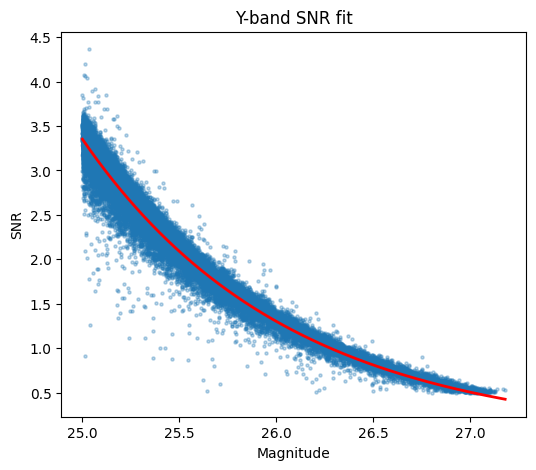

1σ depth = 26.28
2σ depth = 25.55
3σ depth = 25.12
4σ depth = 24.81
5σ depth = 24.58

i-band fit parameters (a, b): [ 8.76274926 -0.93519867]


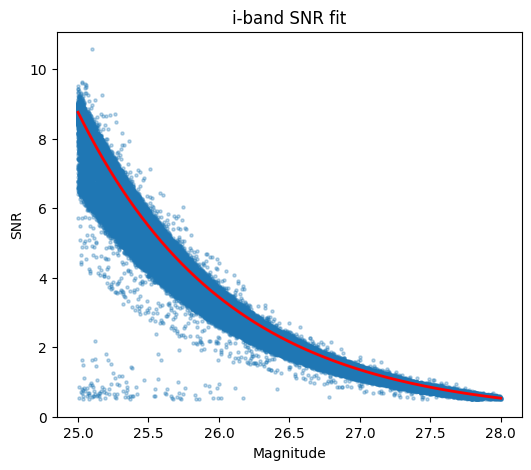

1σ depth = 27.32
2σ depth = 26.58
3σ depth = 26.15
4σ depth = 25.84
5σ depth = 25.60

z-band fit parameters (a, b): [ 7.87507348 -0.90105242]


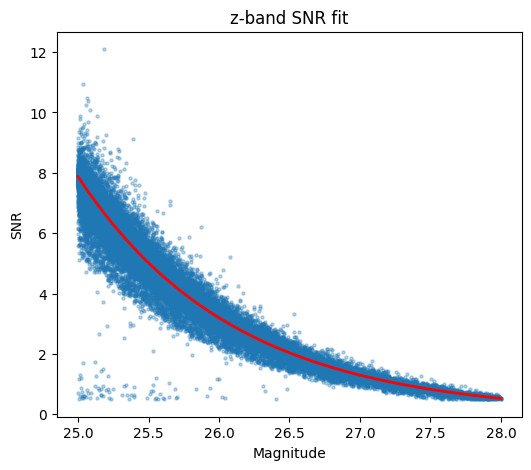

1σ depth = 27.29
2σ depth = 26.52
3σ depth = 26.07
4σ depth = 25.75
5σ depth = 25.50

Final depth summary (mag):
1σ:  Y=26.28   i=27.32   z=27.29
2σ:  Y=25.55   i=26.58   z=26.52
3σ:  Y=25.12   i=26.15   z=26.07
4σ:  Y=24.81   i=25.84   z=25.75
5σ:  Y=24.58   i=25.60   z=25.50


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, brentq


i_file  = "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/i_band_depth.cat"
z_file  = "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/z_band_depth.cat"
y_file  = "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/LBG_Y_Y_final.cat"


colnames = ["ID", "X", "Y", "RA", "DEC",
            "MAG_APER", "MAGERR_APER",
            "MAG_AUTO", "MAGERR_AUTO", "FLAGS"]

i_df = pd.read_csv(i_file, sep=r"\s+", comment="#", names=colnames)
z_df = pd.read_csv(z_file, sep=r"\s+", comment="#", names=colnames)
y_df = pd.read_csv(y_file, sep=r"\s+", comment="#", names=colnames)


ZP_i, ZP_z, ZP_y = 30.8603, 30.4519, 28.2513
ZPe_i, ZPe_z, ZPe_y = 0.0024, 0.0036, 0.0029

for df, zp, zpe in zip([i_df, z_df, y_df], [ZP_i, ZP_z, ZP_y], [ZPe_i, ZPe_z, ZPe_y]):
    df["MAG_CAL"] = df["MAG_APER"] + zp
    df["MAGERR_CAL"] = np.sqrt(df["MAGERR_APER"]**2 + zpe**2)


# Exponential SNR model 
# SNR(m) = a * exp(b*(m - k))


def snr_model(m, a, b):
    return a * np.exp(b * (m - 25))


def fit_snr_exponential(mag, magerr, bandname):

    # Clean data
    valid = np.isfinite(mag) & np.isfinite(magerr) & (mag < 50)
    mag = mag[valid]
    magerr = magerr[valid]

    # Convert to SNR 
    snr = (2.5 / np.log(10)) / magerr


    mask = (0.5 < snr) & (snr < 30)
    mag = mag[mask]
    snr = snr[mask]

    # Fit range similar 
    fit_mask = (mag > 25) & (mag < 28)
    mag = mag[fit_mask]
    snr = snr[fit_mask]

    popt, _ = curve_fit(snr_model, mag, snr, p0=[1000, -0.9])

    print(f"\n{bandname} fit parameters (a, b):", popt)

    # Plot
    x = np.linspace(mag.min(), mag.max(), 1000)
    plt.figure(figsize=(6,5))
    plt.scatter(mag, snr, s=5, alpha=0.3)
    plt.plot(x, snr_model(x, *popt), lw=2, color='red')
    plt.xlabel("Magnitude")
    plt.ylabel("SNR")
    plt.title(f"{bandname} SNR fit")
    plt.show()

    # ========================================================
    # Compute depths
    # ========================================================
    depths = {}

    for N in [1,2,3,4,5]:

        def root_func(m):
            return snr_model(m, *popt) - N

        try:
            mN = brentq(root_func, 20, 30)
            depths[N] = mN
            print(f"{N}σ depth = {mN:.2f}")
        except:
            depths[N] = np.nan

    return popt, depths




popt_y, depths_y = fit_snr_exponential(y_df["MAG_CAL"].values,
                                       y_df["MAGERR_CAL"].values,
                                       "Y-band")

popt_i, depths_i = fit_snr_exponential(i_df["MAG_CAL"].values,
                                       i_df["MAGERR_CAL"].values,
                                       "i-band")

popt_z, depths_z = fit_snr_exponential(z_df["MAG_CAL"].values,
                                       z_df["MAGERR_CAL"].values,
                                       "z-band")

print("\nFinal depth summary (mag):")
for N in [1,2,3,4,5]:
    print(f"{N}σ:  Y={depths_y[N]:.2f}   i={depths_i[N]:.2f}   z={depths_z[N]:.2f}")


Y-band fit parameters (a, b): [ 1.73670236 -0.92418623]


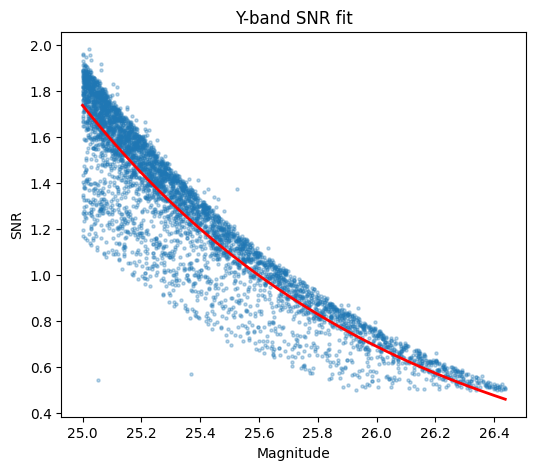

1σ depth = 25.60
2σ depth = 24.85
3σ depth = 24.41
4σ depth = 24.10
5σ depth = 23.86

i-band fit parameters (a, b): [ 8.76274926 -0.93519867]


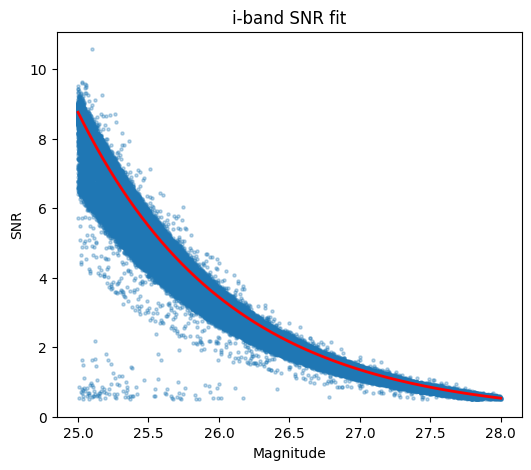

1σ depth = 27.32
2σ depth = 26.58
3σ depth = 26.15
4σ depth = 25.84
5σ depth = 25.60

z-band fit parameters (a, b): [ 7.87507348 -0.90105242]


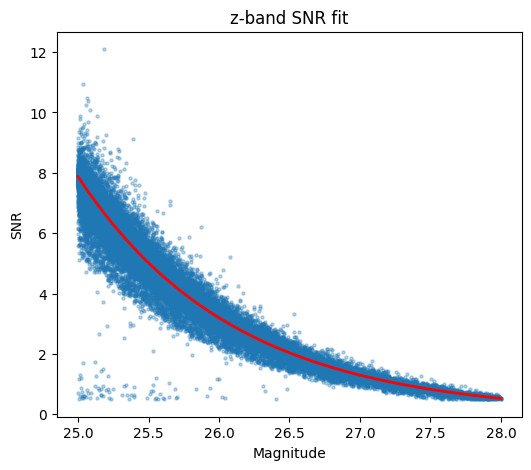

1σ depth = 27.29
2σ depth = 26.52
3σ depth = 26.07
4σ depth = 25.75
5σ depth = 25.50

Final depth summary (mag):
1σ:  Y=25.60   i=27.32   z=27.29
2σ:  Y=24.85   i=26.58   z=26.52
3σ:  Y=24.41   i=26.15   z=26.07
4σ:  Y=24.10   i=25.84   z=25.75
5σ:  Y=23.86   i=25.60   z=25.50


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, brentq


i_file  = "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/i_band_depth.cat"
z_file  = "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/z_band_depth.cat"
y_file  = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Y_CDFS_depth.cat"


colnames = ["ID", "X", "Y", "RA", "DEC",
            "MAG_APER", "MAGERR_APER",
            "MAG_AUTO", "MAGERR_AUTO", "FLAGS"]

i_df = pd.read_csv(i_file, sep=r"\s+", comment="#", names=colnames)
z_df = pd.read_csv(z_file, sep=r"\s+", comment="#", names=colnames)
y_df = pd.read_csv(y_file, sep=r"\s+", comment="#", names=colnames)


ZP_i, ZP_z, ZP_y = 30.8603, 30.4519, 30.3382
ZPe_i, ZPe_z, ZPe_y = 0.0024, 0.0036, 0.009

for df, zp, zpe in zip([i_df, z_df, y_df], [ZP_i, ZP_z, ZP_y], [ZPe_i, ZPe_z, ZPe_y]):
    df["MAG_CAL"] = df["MAG_APER"] + zp
    df["MAGERR_CAL"] = np.sqrt(df["MAGERR_APER"]**2 + zpe**2)


# Exponential SNR model 
# SNR(m) = a * exp(b*(m - k))


def snr_model(m, a, b):
    return a * np.exp(b * (m - 25))


def fit_snr_exponential(mag, magerr, bandname):

    # Clean data
    valid = np.isfinite(mag) & np.isfinite(magerr) & (mag < 50)
    mag = mag[valid]
    magerr = magerr[valid]

    # Convert to SNR 
    snr = (2.5 / np.log(10)) / magerr


    mask = (0.5 < snr) & (snr < 30)
    mag = mag[mask]
    snr = snr[mask]

    # Fit range similar 
    fit_mask = (mag > 25) & (mag < 28)
    mag = mag[fit_mask]
    snr = snr[fit_mask]

    popt, _ = curve_fit(snr_model, mag, snr, p0=[1000, -0.9])

    print(f"\n{bandname} fit parameters (a, b):", popt)

    # Plot
    x = np.linspace(mag.min(), mag.max(), 1000)
    plt.figure(figsize=(6,5))
    plt.scatter(mag, snr, s=5, alpha=0.3)
    plt.plot(x, snr_model(x, *popt), lw=2, color='red')
    plt.xlabel("Magnitude")
    plt.ylabel("SNR")
    plt.title(f"{bandname} SNR fit")
    plt.show()

    # ========================================================
    # Compute depths
    # ========================================================
    depths = {}

    for N in [1,2,3,4,5]:

        def root_func(m):
            return snr_model(m, *popt) - N

        try:
            mN = brentq(root_func, 20, 30)
            depths[N] = mN
            print(f"{N}σ depth = {mN:.2f}")
        except:
            depths[N] = np.nan

    return popt, depths




popt_y, depths_y = fit_snr_exponential(y_df["MAG_CAL"].values,
                                       y_df["MAGERR_CAL"].values,
                                       "Y-band")

popt_i, depths_i = fit_snr_exponential(i_df["MAG_CAL"].values,
                                       i_df["MAGERR_CAL"].values,
                                       "i-band")

popt_z, depths_z = fit_snr_exponential(z_df["MAG_CAL"].values,
                                       z_df["MAGERR_CAL"].values,
                                       "z-band")

print("\nFinal depth summary (mag):")
for N in [1,2,3,4,5]:
    print(f"{N}σ:  Y={depths_y[N]:.2f}   i={depths_i[N]:.2f}   z={depths_z[N]:.2f}")